# Mental Health Detection Model Building

This notebook builds a machine learning model to detect mental health risks from text keywords using the Combined Data.csv dataset.

It performs exploratory data analysis and trains multiple models for comparison.

In [1]:
# Install required packages
!pip3 install pandas numpy scikit-learn matplotlib seaborn nltk transformers torch

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 6.5 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 28.1 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 24.4 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 16.2 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 12.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.5 MB 20.3 MB/s eta 0:00:01
  Using cached transformers-4.57.6-py3-none-any.whl (12.0 MB)
  Using cached torch-2.8.0-cp39-none-macosx_11_0_arm64.whl (73.6 MB)
     |████████████████████████████████| 349 kB 27.5 MB/s eta 0:00:01
     |████████████████████████████████| 229 kB 12.7 MB/s eta 0:00:01
     |████████████████████████████████| 510 kB 3.8 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 13.6 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 28.7 MB/s eta 0:00:01
     |█████████████████████████

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

print("Libraries imported and preprocessing pipeline ready.")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tht_developers/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tht_developers/nltk_data...


Libraries imported and preprocessing pipeline ready.


In [ ]:
# pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load the dataset
df = pd.read_csv('../app/db/Combined Data.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.info())

Dataset shape: (53043, 3)
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  53043 non-null  int64
 1   statement   52681 non-null  str  
 2   status      53043 non-null  str  
dtypes: int64(1), str(2)
memory usage: 30.8 MB
None


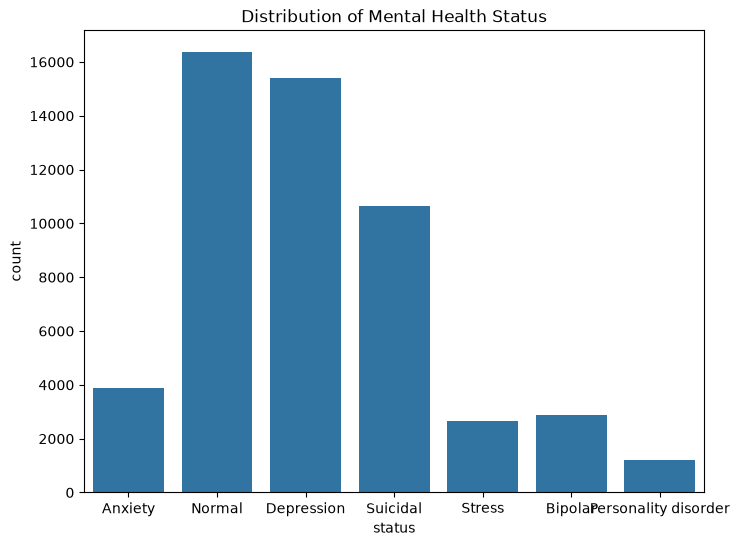

Unnamed: 0      0
statement     362
status          0
dtype: int64


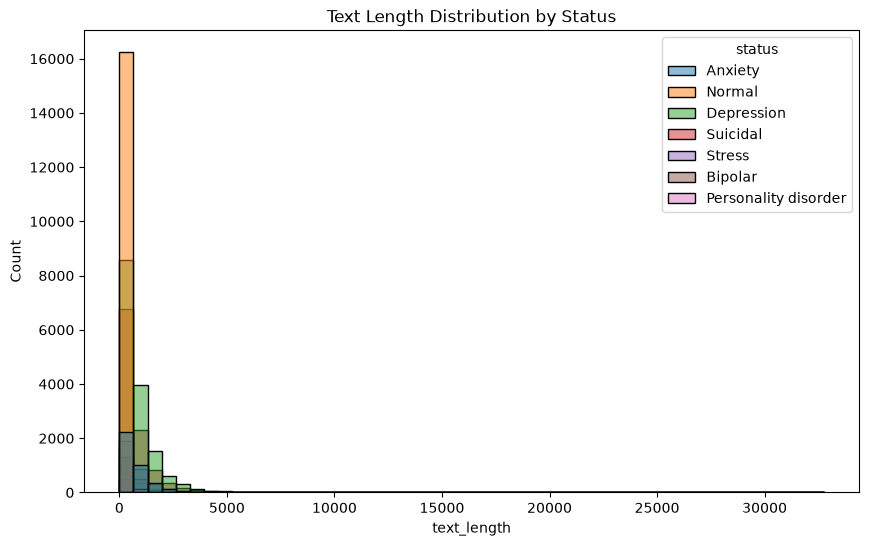

In [3]:
# Exploratory Data Analysis
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='status')  # Assuming 'status' is the target column
plt.title('Distribution of Mental Health Status')
plt.show()

# Check for missing values
print(df.isnull().sum())

# Handle missing values
df = df.dropna(subset=['statement'])

# Text length analysis
df['text_length'] = df['statement'].apply(len)  # Assuming 'statement' is the text column
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='text_length', hue='status', bins=50)
plt.title('Text Length Distribution by Status')
plt.show()

In [5]:
# Text Preprocessing
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize and remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

df['cleaned_text'] = df['statement'].apply(preprocess_text)
print(df[['statement', 'cleaned_text']].head())

                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                        cleaned_text  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  
3  ive shifted focus something else im still worried  
4                im restless restless month boy mean  


In [6]:
# Feature Extraction
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['cleaned_text'])
y = df['status']

# Encode labels if needed
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Classes: {le.classes_}")

Training set shape: (42144, 5000)
Test set shape: (10537, 5000)
Classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [7]:
# Model Training and Evaluation
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.savefig(f'cm_{name}.png')
    plt.close()

    results[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'classification_report': classification_report(y_test, y_pred, target_names=le.classes_)
    }

    print(f"{name} - Accuracy: {accuracy:.4f}, ROC-AUC: {roc_auc:.4f}")

# Print detailed results
for name, result in results.items():
    print(f"\n{name}:")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print(f"ROC-AUC: {result['roc_auc']:.4f}")
    print("Classification Report:")
    print(result['classification_report'])

Logistic Regression - Accuracy: 0.7607, ROC-AUC: 0.9549


/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM - Accuracy: 0.7740, ROC-AUC: 0.9600
Random Forest - Accuracy: 0.7286, ROC-AUC: 0.9395

Logistic Regression:
Accuracy: 0.7607
ROC-AUC: 0.9549
Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.83      0.73      0.78       768
             Bipolar       0.86      0.70      0.77       556
          Depression       0.70      0.74      0.72      3081
              Normal       0.83      0.95      0.89      3269
Personality disorder       0.80      0.51      0.62       215
              Stress       0.65      0.42      0.51       517
            Suicidal       0.69      0.63      0.66      2131

            accuracy                           0.76     10537
           macro avg       0.77      0.67      0.71     10537
        weighted avg       0.76      0.76      0.75     10537


SVM:
Accuracy: 0.7740
ROC-AUC: 0.9600
Classification Report:
                      precision    recall  f1-score   support

             Anxiety  

In [ ]:
# Cross-validation for robustness
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
    print(f"{name} CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

In [ ]:
# Feature Importance (for Random Forest)
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [ ]:
# Save the best model
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = models[best_model_name]

print(f"Best model: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

# Save the TF-IDF vectorizer as well
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(best_model, 'best_mental_health_model.pkl')

## Summary

This notebook performed the following:
- Loaded and explored the Combined Data.csv dataset
- Preprocessed text data using NLTK
- Extracted features using TF-IDF
- Trained and evaluated multiple models: Logistic Regression, SVM, and Random Forest
- Identified the best performing model based on ROC-AUC

The trained model can be used for mental health risk detection in the chatbot application.